# Type 2 Diabetes — Exploratory Data Analysis

**Dataset:** `research_grade_type2_diabetes_dataset_v3.csv`  
**Target:** `stage` — diabetes progression stage  
**Goal:** Understand data quality, distribution of the target, and identify key clinical features that drive disease progression.

---

## Research Questions

1. **Target structure** — Is `stage` continuous or ordinal? Skewed? This determines whether we treat the problem as regression or ordinal classification.  
2. **Clinical drivers** — Which biomarkers (glucose, BMI, HbA1c, etc.) have the strongest monotonic relationship with disease stage?  
3. **Non-linearity** — Do Pearson and Spearman correlations diverge? If so, tree-based models are likely necessary.  
4. **Data quality** — Missing values, duplicates, physiologically implausible outliers?  
5. **Feature redundancy** — Are any predictors highly inter-correlated (multicollinearity risk for linear models)?

---

**Sections:**
1. Setup & Data Loading  
2. Initial Inspection  
3. Data Quality — Missingness, Duplicates, Outliers  
4. Target Variable Analysis  
5. Numeric Feature Distributions  
6. Categorical Feature Analysis  
7. Correlation Analysis  
8. Feature–Target Relationships  
9. Summary & Modelling Plan  


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

SEED   = 42
TARGET = 'stage'
np.random.seed(SEED)

df = pd.read_csv('Data/research_grade_type2_diabetes_dataset_v3.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

Loaded: 496,362 rows × 35 columns
Memory: 222.23 MB


## 2. Initial Inspection

First look at column names, dtypes, and summary statistics. Pay attention to:
- Whether `stage` is integer (ordinal classes) or float (continuous)
- Any columns with unexpected dtypes (e.g. numeric stored as object)
- Range of clinical values — physiologically implausible values are a data quality flag


In [2]:
df.head(10)

,patient_id,year,country,age,gender,BMI,family_history,fasting_glucose,HbA1c,insulin,HOMA_IR,triglycerides,HDL,LDL,blood_pressure,daily_calories,sugar_intake,physical_activity,sleep_hours,stress_level,sedentary_hours,stage,geo_risk_factor,on_medication,alive,smoking,alcohol,BMI_category,risk_score,future_diabetes_risk,glucose_prev,bmi_prev,diabetes_onset,onset_year,future_diabetes_5yr
0,1,1976,Sri Lanka,25,Male,22.7055,1,93.1933,4.7168,8.1838,1.6719,204.3775,38.6884,146.2107,157.3558,1875.1450,107.6018,medium,6.6234,3,5.5084,0,0.0000,0,1,0,0,Normal,19.5524,0,92.5181,22.3533,0,NaN,0
1,1,1977,Sri Lanka,26,Male,22.1921,1,86.9491,4.8279,8.6760,2.0824,198.2327,38.4212,134.4591,132.3860,2602.2749,87.7425,medium,5.8324,7,9.3907,0,0.0000,0,1,0,0,Normal,19.9108,0,92.5181,22.3533,0,NaN,0
2,1,1978,Sri Lanka,27,Male,22.9016,1,84.9855,4.9056,11.4223,2.6981,207.5283,25.0854,92.0516,119.0682,2669.9739,104.3162,medium,8.1188,9,0.4903,0,0.0000,0,1,1,0,Normal,19.5082,0,86.3288,23.4336,0,NaN,0
3,1,1979,Sri Lanka,28,Male,25.7354,1,92.7065,5.0404,10.8099,3.0409,173.7092,21.4728,104.4512,144.4976,2351.8083,107.0466,medium,8.9555,7,7.9869,0,0.0000,0,1,1,0,Overweight,21.7635,0,93.5602,24.3465,0,NaN,0
4,1,1980,Sri Lanka,29,Male,26.0186,1,97.2079,4.8670,13.0510,3.5738,218.9737,22.8342,128.3453,132.2258,2726.4039,107.9271,medium,5.8304,9,3.4683,0,0.0000,0,1,1,1,Overweight,22.2751,0,103.8338,26.2964,0,NaN,0
5,1,1981,Sri Lanka,30,Male,22.2616,1,81.0887,4.9800,16.3475,4.4846,192.2377,29.3276,129.9403,146.6717,3275.6961,121.5061,medium,8.2356,2,1.5991,0,0.0000,0,1,1,1,Normal,17.5734,0,88.8329,23.2357,0,NaN,0
6,1,1982,Sri Lanka,31,Male,22.5623,1,105.6055,5.0660,19.6032,4.9999,185.7116,32.1335,134.7316,130.0339,2851.7362,78.0709,medium,5.6945,9,4.4801,0,0.0000,0,1,1,1,Normal,21.8335,0,101.3012,22.9931,0,NaN,0
7,1,1983,Sri Lanka,32,Male,24.2984,1,73.2291,4.1973,21.5882,5.0000,162.0669,33.2284,122.0678,121.5747,2359.8759,114.8307,medium,8.5075,5,6.1807,2,0.0000,1,1,0,0,Normal,18.6603,0,92.7293,23.1468,0,NaN,0
8,1,1984,Sri Lanka,33,Male,26.1465,1,89.5658,4.9616,20.0284,5.0000,218.6049,29.5958,113.0812,146.3083,2377.2324,120.1827,medium,9.1078,1,10.1770,2,0.0000,0,1,0,0,Overweight,20.6329,0,98.4294,24.7260,0,NaN,0
9,1,1985,Sri Lanka,34,Male,23.5723,1,74.1332,3.6329,26.6604,5.0000,182.3353,31.2083,141.3620,141.3342,1881.9414,107.0578,medium,8.3897,9,4.9298,2,0.0000,1,1,1,1,Normal,19.1352,0,96.1909,23.6876,0,NaN,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496362 entries, 0 to 496361
Data columns (total 35 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   patient_id            496362 non-null  int64  
 1   year                  496362 non-null  int64  
 2   country               496362 non-null  object 
 3   age                   496362 non-null  int64  
 4   gender                496362 non-null  object 
 5   BMI                   496362 non-null  float64
 6   family_history        496362 non-null  int64  
 7   fasting_glucose       496362 non-null  float64
 8   HbA1c                 496362 non-null  float64
 9   insulin               496362 non-null  float64
 10  HOMA_IR               496362 non-null  float64
 11  triglycerides         496362 non-null  float64
 12  HDL                   496362 non-null  float64
 13  LDL                   496362 non-null  float64
 14  blood_pressure        496362 non-null  float64
 15  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,496362.0000,5000.6371,2887.1158,1.0000,2500.0000,5001.0000,7502.0000,10000.0000
year,496362.0000,2000.4798,14.5563,1976.0000,1988.0000,2000.0000,2013.0000,2026.0000
age,496362.0000,53.8618,15.7517,19.0000,41.0000,54.0000,66.0000,90.0000
BMI,496362.0000,26.0387,6.0567,11.1949,22.0896,25.6994,29.7790,50.4451
family_history,496362.0000,0.2964,0.4567,0.0000,0.0000,0.0000,1.0000,1.0000
fasting_glucose,496362.0000,111.8615,38.0721,70.0000,83.3074,100.8096,131.7293,250.0000
HbA1c,496362.0000,5.4586,1.3600,1.9916,4.4953,5.0597,6.1515,12.0000
insulin,496362.0000,24.2713,10.4450,2.0000,15.5418,23.4365,33.6431,40.0000
HOMA_IR,496362.0000,4.3473,1.0415,0.5000,3.8097,5.0000,5.0000,5.0000
triglycerides,496362.0000,206.1589,28.3640,84.5864,186.9145,206.0210,225.2102,341.1152


## 3. Data Quality

### 3.1 Missingness

Decision rule:
- **< 5%** → median / mode imputation  
- **5–30%** → impute + add binary missingness indicator flag  
- **> 30%** → consider dropping the column


Columns with missing values: 1 of 35
             count     pct             action
onset_year  280315 56.4739  consider dropping


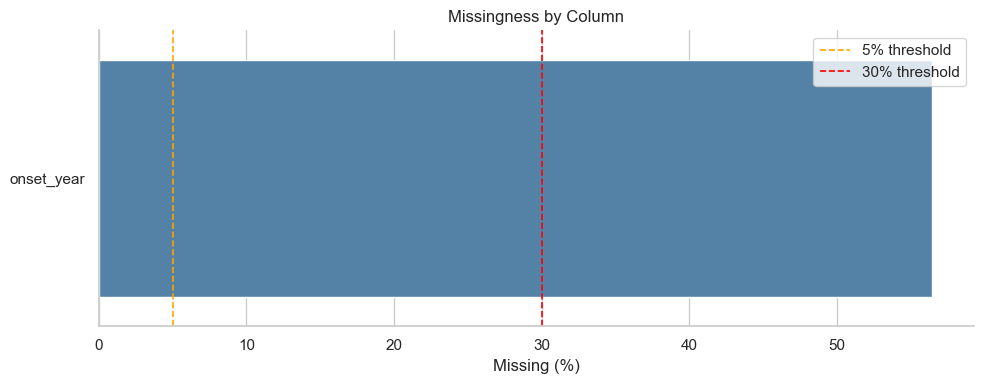

In [5]:
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'pct':   df.isnull().mean() * 100
}).query('count > 0').sort_values('pct', ascending=False)

print(f'Columns with missing values: {len(missing)} of {df.shape[1]}')

if len(missing) > 0:
    missing['action'] = missing['pct'].apply(
        lambda p: 'impute (median/mode)' if p < 5
                  else 'impute + flag' if p < 30
                  else 'consider dropping'
    )
    print(missing.to_string())

    plot_df = missing.reset_index().rename(columns={'index': 'column'})
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=plot_df, x='pct', y='column', color='steelblue', ax=ax)
    ax.axvline(5,  color='orange', linestyle='--', linewidth=1.2, label='5% threshold')
    ax.axvline(30, color='red',    linestyle='--', linewidth=1.2, label='30% threshold')
    ax.set_xlabel('Missing (%)')
    ax.set_ylabel('')
    ax.set_title('Missingness by Column')
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print('No missing values.')

### 3.2 Duplicates

In [6]:
n_dups = df.duplicated().sum()
print(f'Full duplicate rows: {n_dups} ({n_dups / len(df) * 100:.2f}%)')
if n_dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Removed. New shape: {df.shape}')

Full duplicate rows: 0 (0.00%)


### 3.3 Outliers

**3×IQR fence** used — conservative threshold appropriate for clinical data where extreme values may be physiologically real (e.g. very high glucose) rather than entry errors. Flagged for review, not automatically removed.


In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

outlier_report = []
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 3 * IQR, Q3 + 3 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    if n_out > 0:
        outlier_report.append({
            'column': col, 'n_outliers': n_out,
            'pct': round(n_out / len(df) * 100, 2),
            'lower_fence': round(lo, 3), 'upper_fence': round(hi, 3)
        })

if outlier_report:
    out_df = pd.DataFrame(outlier_report).sort_values('pct', ascending=False)
    print('Outliers (3×IQR) — flagged, not removed:')
    print(out_df.to_string(index=False))
else:
    print('No outliers at 3×IQR threshold.')

Outliers (3×IQR) — flagged, not removed:
         column  n_outliers    pct  lower_fence  upper_fence
geo_risk_factor        7616 1.5300       0.0000       0.0000
          HbA1c         342 0.0700      -0.4730      11.1200
  triglycerides           1 0.0000      72.0270     340.0970
            LDL           1 0.0000      49.8090     202.3230
 daily_calories           2 0.0000    1070.0810    4232.6430
   glucose_prev          15 0.0000     -57.9370     296.3640


## 4. Target Variable Analysis

`stage` is the diabetes progression stage. Key questions:
- **Continuous vs ordinal?** Integer values with few unique levels → ordinal classification. Float with many values → regression.  
- **Skewness** — affects choice of loss function. Heavy right-skew → log-transform target or use MAE-based loss.  
- **Class balance** (if ordinal) — severe imbalance requires stratified splits and appropriate metrics (weighted F1 / macro AUC).


Unique values of stage: 3
stage
0    137794
2    142521
3    216047
Name: count, dtype: int64



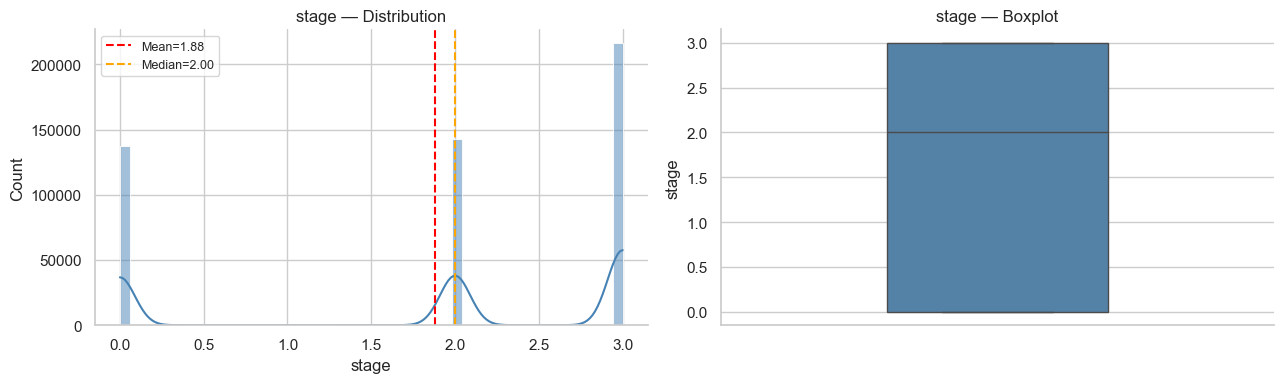

Skewness : -0.651  → approx. symmetric
Kurtosis : -1.229  
Min / Max: 0 / 3


In [8]:
print(f'Unique values of {TARGET}: {df[TARGET].nunique()}')
print(df[TARGET].value_counts().sort_index())
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram with KDE
sns.histplot(df[TARGET], bins=50, kde=True, color='steelblue',
             edgecolor='white', ax=axes[0])
axes[0].axvline(df[TARGET].mean(),   color='red',    linestyle='--',
                label=f'Mean={df[TARGET].mean():.2f}')
axes[0].axvline(df[TARGET].median(), color='orange', linestyle='--',
                label=f'Median={df[TARGET].median():.2f}')
axes[0].set_title(f'{TARGET} — Distribution')
axes[0].set_xlabel(TARGET)
axes[0].legend(fontsize=9)

# Boxplot
sns.boxplot(y=df[TARGET], color='steelblue', width=0.4, ax=axes[1])
axes[1].set_title(f'{TARGET} — Boxplot')
axes[1].set_ylabel(TARGET)

sns.despine()
plt.tight_layout()
plt.show()

skew = df[TARGET].skew()
kurt = df[TARGET].kurt()
print(f'Skewness : {skew:.3f}  {"→ right-skewed" if skew>1 else "→ left-skewed" if skew<-1 else "→ approx. symmetric"}')
print(f'Kurtosis : {kurt:.3f}  {"→ heavy tails" if kurt>3 else ""}')
print(f'Min / Max: {df[TARGET].min()} / {df[TARGET].max()}')

## 5. Numeric Feature Distributions

Grid of histograms for all numeric columns. Skewness annotated on each — right-skewed features (skew > 1) are candidates for log-transform before linear modelling.


Numeric columns: 31


/var/folders/8_/15h_tlqd1n9_60krp8hv139c0000gn/T/ipykernel_47577/2585093292.py:23: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


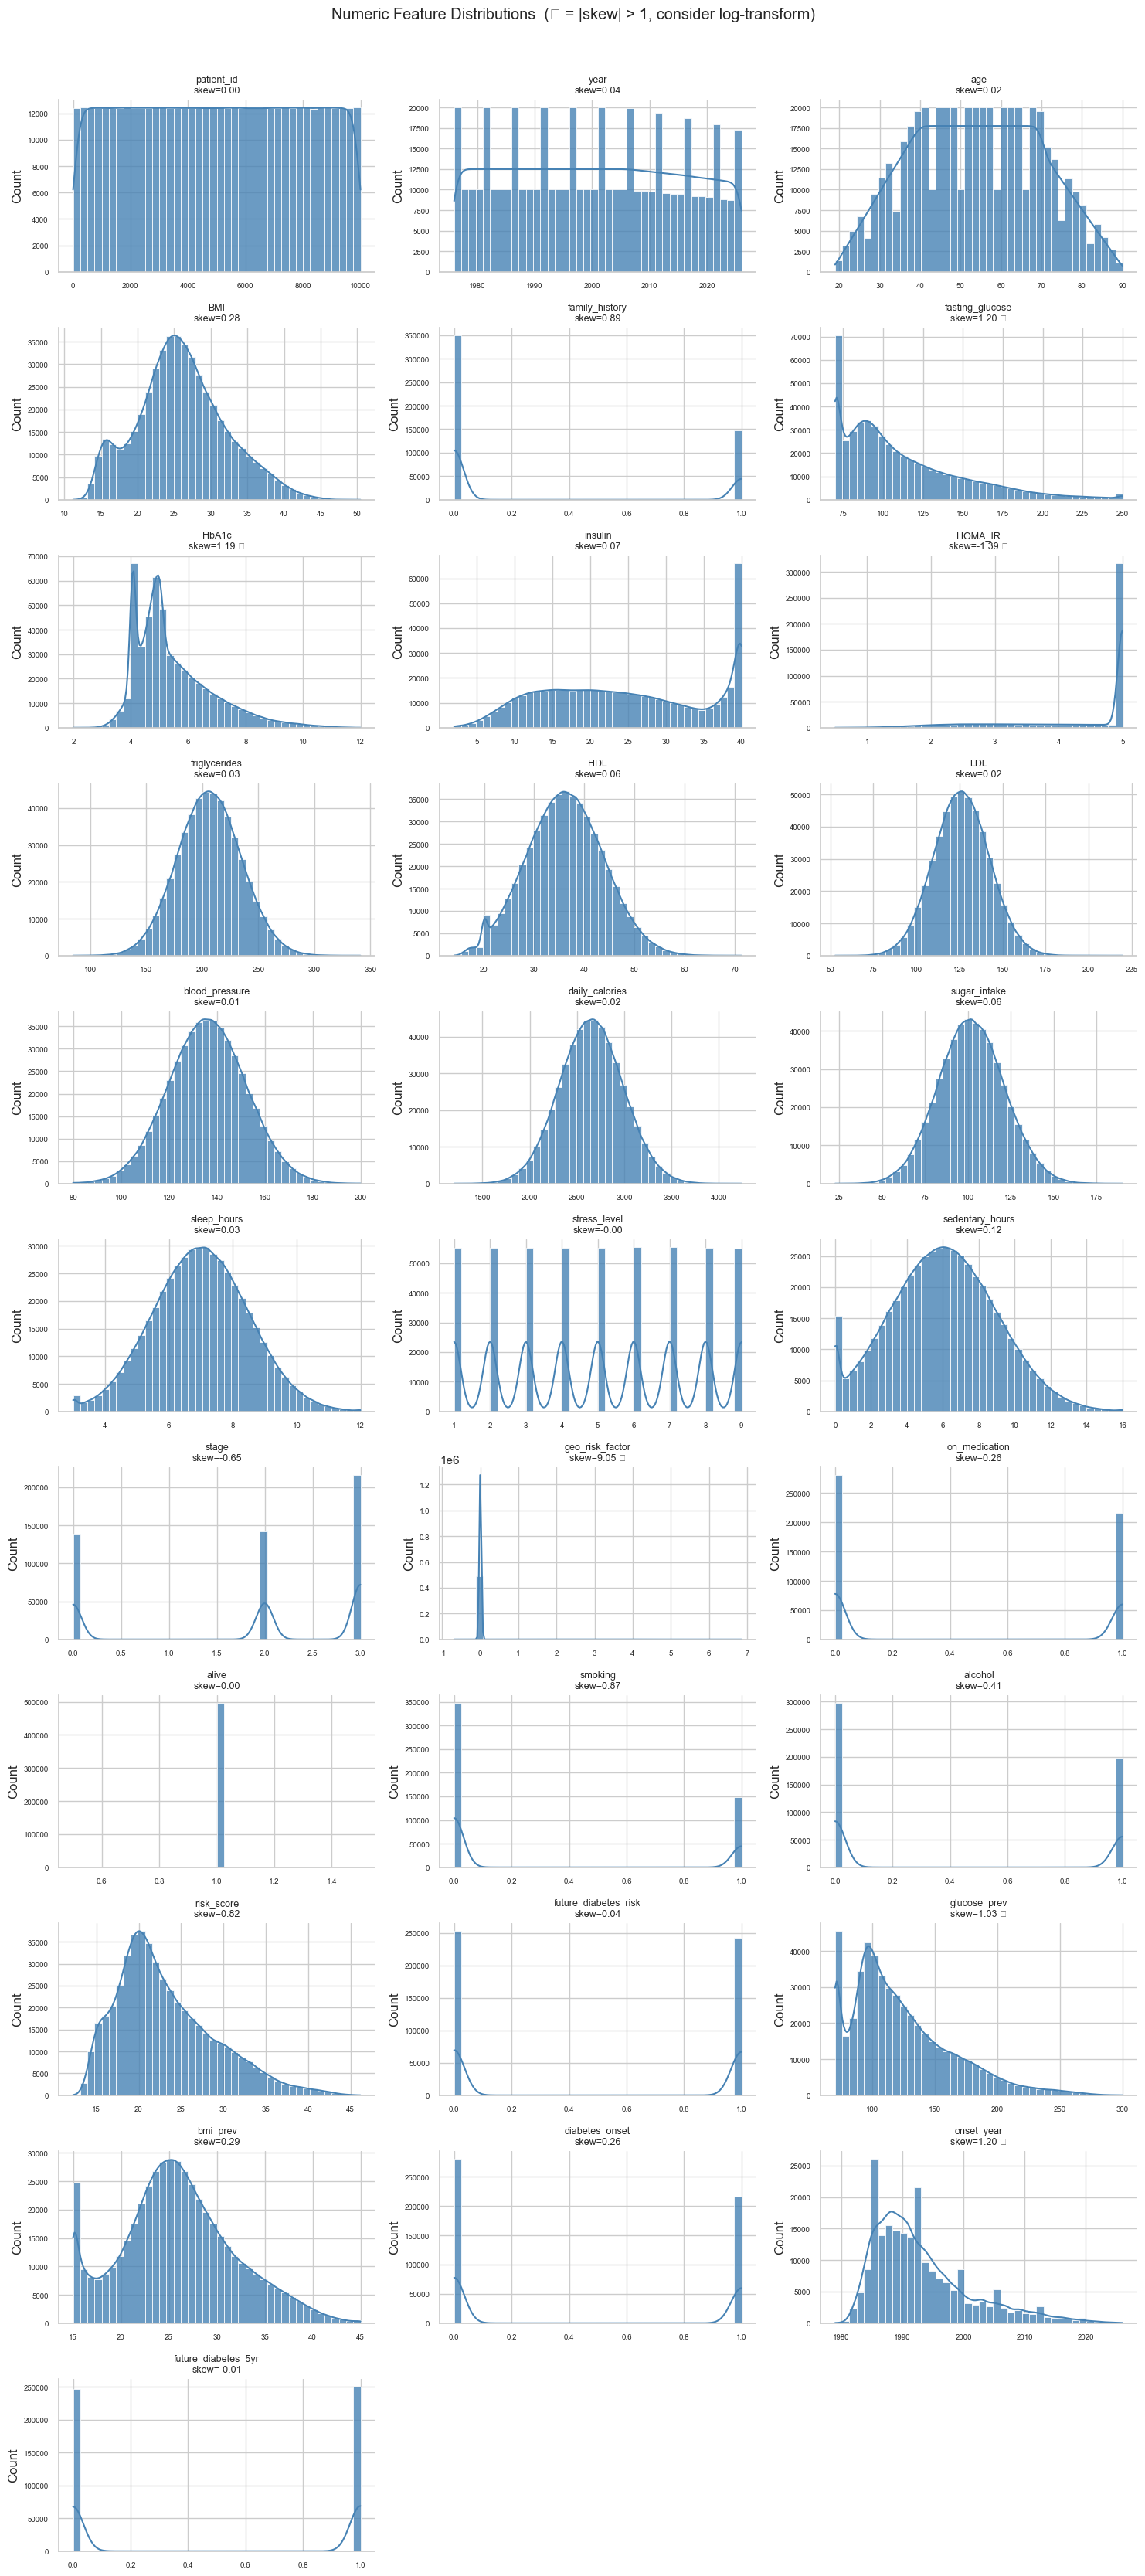

In [9]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f'Numeric columns: {len(num_cols)}')

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), bins=40, kde=True, color='steelblue',
                 edgecolor='white', alpha=0.8, ax=axes[i])
    skew = df[col].skew()
    flag = ' ⚠' if abs(skew) > 1 else ''
    axes[i].set_title(f'{col}\nskew={skew:.2f}{flag}', fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)
    sns.despine(ax=axes[i])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions  (⚠ = |skew| > 1, consider log-transform)', y=1.01)
plt.tight_layout()
plt.show()

## 6. Categorical Feature Analysis

Cardinality reported per column. High-cardinality columns (> 20 unique values) are flagged — they require target-encoding or should be dropped before modelling to avoid dimensionality explosion from one-hot encoding.


Categorical columns: 4

country: 193 unique values  ⚠ HIGH CARDINALITY
country
Solomon Islands    3762
Montenegro         3489
Cuba               3482
Djibouti           3380
Liechtenstein      3368
Dominica           3324
Mauritania         3300
Seychelles         3270
Hungary            3270
Liberia            3251

gender: 2 unique values
gender
Female    248460
Male      247902


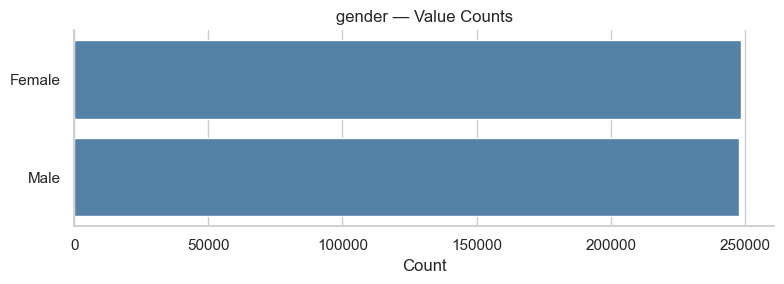


physical_activity: 3 unique values
physical_activity
medium    197901
low       196451
high      102010


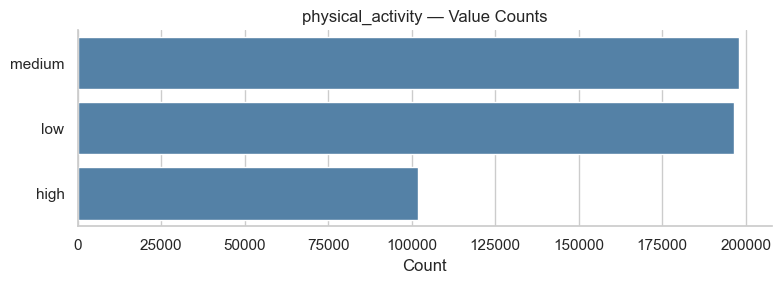


BMI_category: 4 unique values
BMI_category
Normal         166203
Overweight     155047
Obese          118956
Underweight     56156


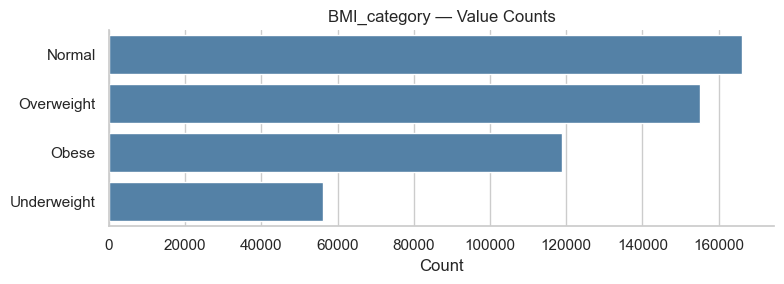

In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {len(cat_cols)}')

for col in cat_cols:
    n_unique = df[col].nunique()
    flag = '  ⚠ HIGH CARDINALITY' if n_unique > 20 else ''
    print(f'\n{col}: {n_unique} unique values{flag}')
    print(df[col].value_counts().head(10).to_string())

    if n_unique <= 20:
        order = df[col].value_counts().head(10).index
        fig, ax = plt.subplots(figsize=(8, 3))
        sns.countplot(data=df, y=col, order=order, color='steelblue', ax=ax)
        ax.set_title(f'{col} — Value Counts')
        ax.set_xlabel('Count')
        ax.set_ylabel('')
        sns.despine()
        plt.tight_layout()
        plt.show()

## 7. Correlation Analysis

**Pearson** — linear association. **Spearman** — monotonic association, robust to outliers and non-normality. For clinical ordinal data, Spearman is preferred.

The `divergence` column (`|Spearman| − |Pearson|`) highlights features with non-linear signal — these benefit most from tree-based models.


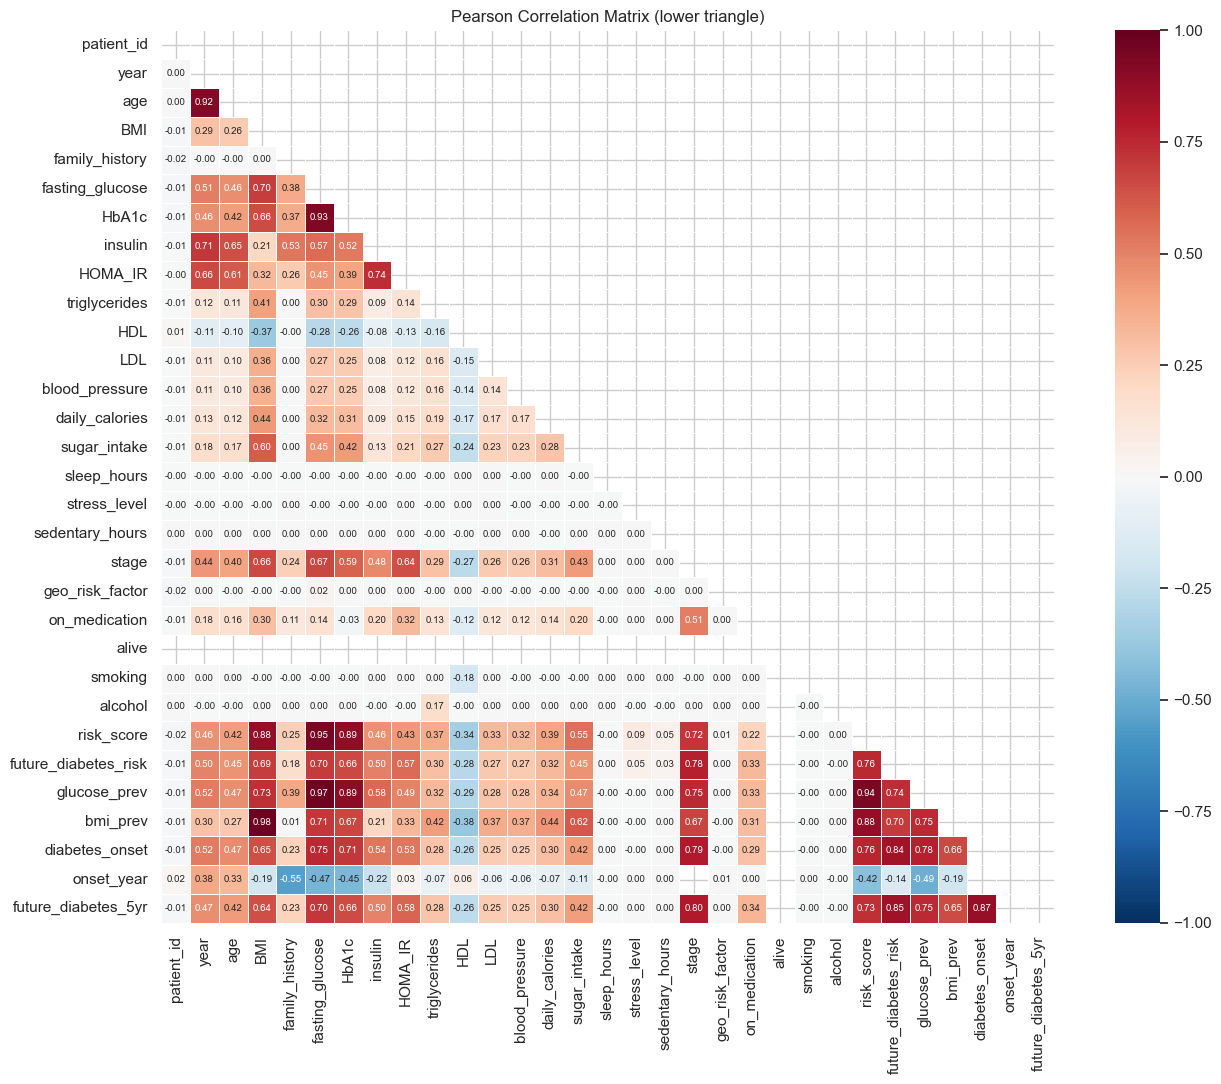

In [11]:
corr = df[num_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Pearson Correlation Matrix (lower triangle)')
plt.tight_layout()
plt.show()

### 7.1 Feature Correlation with Target

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Feature correlations with stage:
                      pearson  spearman  divergence
diabetes_onset         0.7945    0.9194      0.1248
glucose_prev           0.7491    0.9026      0.1535
future_diabetes_5yr    0.8012    0.8716      0.0705
future_diabetes_risk   0.7775    0.8447      0.0673
risk_score             0.7175    0.8370      0.1195
fasting_glucose        0.6712    0.8256      0.1543
bmi_prev               0.6723    0.7294      0.0571
HbA1c                  0.5892    0.7202      0.1310
BMI                    0.6599    0.7137      0.0538
HOMA_IR                0.6449    0.6967      0.0518
insulin                0.4788    0.5308      0.0520
year                   0.4405    0.4971      0.0566
age                    0.4006    0.4520      0.0514
on_medication          0.5102    0.4487     -0.0615
sugar_intake           0.4295    0.4467      0.0171
daily_calories         0.3097    0.3183      0.0086
triglycerides          0.2919    0.2988      0.0069
HDL                   -0.2667  

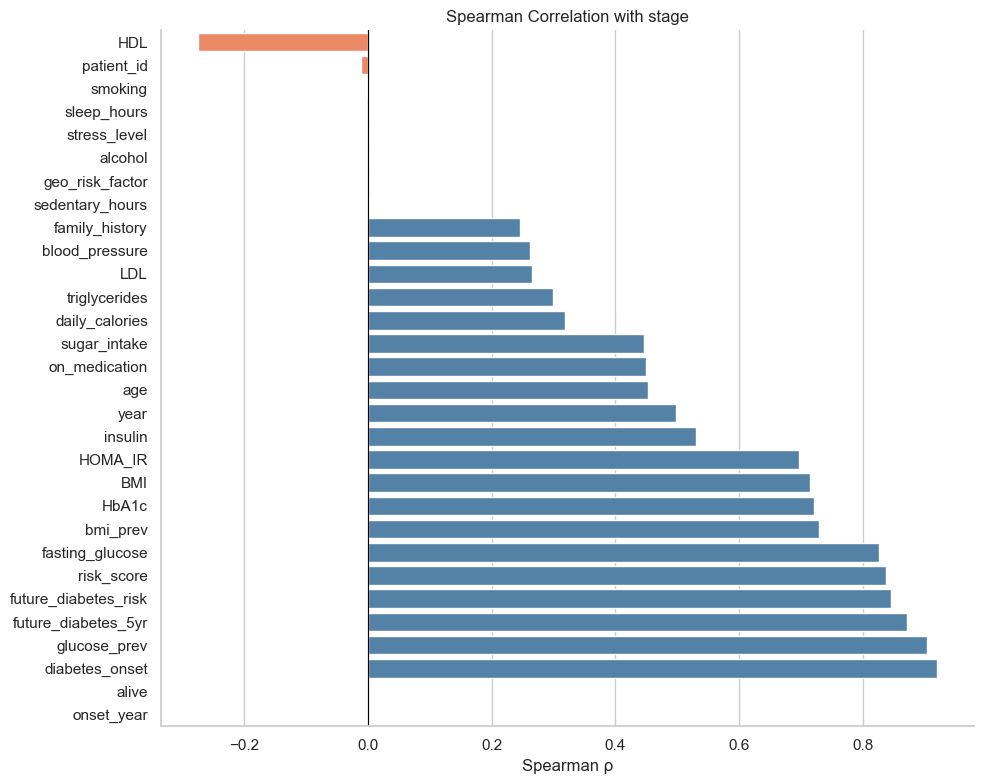

In [12]:
feat_cols = [c for c in num_cols if c != TARGET]
target_corr = pd.DataFrame({
    'pearson' : [df[c].corr(df[TARGET], method='pearson')  for c in feat_cols],
    'spearman': [df[c].corr(df[TARGET], method='spearman') for c in feat_cols],
}, index=feat_cols)
target_corr['abs_spearman'] = target_corr['spearman'].abs()
target_corr['divergence']   = target_corr['spearman'].abs() - target_corr['pearson'].abs()
target_corr = target_corr.sort_values('abs_spearman', ascending=False)

print(f'Feature correlations with {TARGET}:')
print(target_corr[['pearson', 'spearman', 'divergence']].to_string())

plot_df = target_corr.reset_index().rename(columns={'index': 'feature'})
plot_df['color'] = plot_df['spearman'].apply(lambda x: 'positive' if x >= 0 else 'negative')

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=plot_df.sort_values('spearman'),
    x='spearman', y='feature',
    hue='color',
    palette={'positive': 'steelblue', 'negative': 'coral'},
    legend=False, ax=ax
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Spearman Correlation with {TARGET}')
ax.set_xlabel('Spearman ρ')
ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

## 8. Feature–Target Scatter Plots

Top-6 features by |Spearman ρ|. Linear trend overlaid — curvature signals non-linearity; fan shape signals heteroskedasticity (error variance grows with predicted value). p-value shown for each correlation.


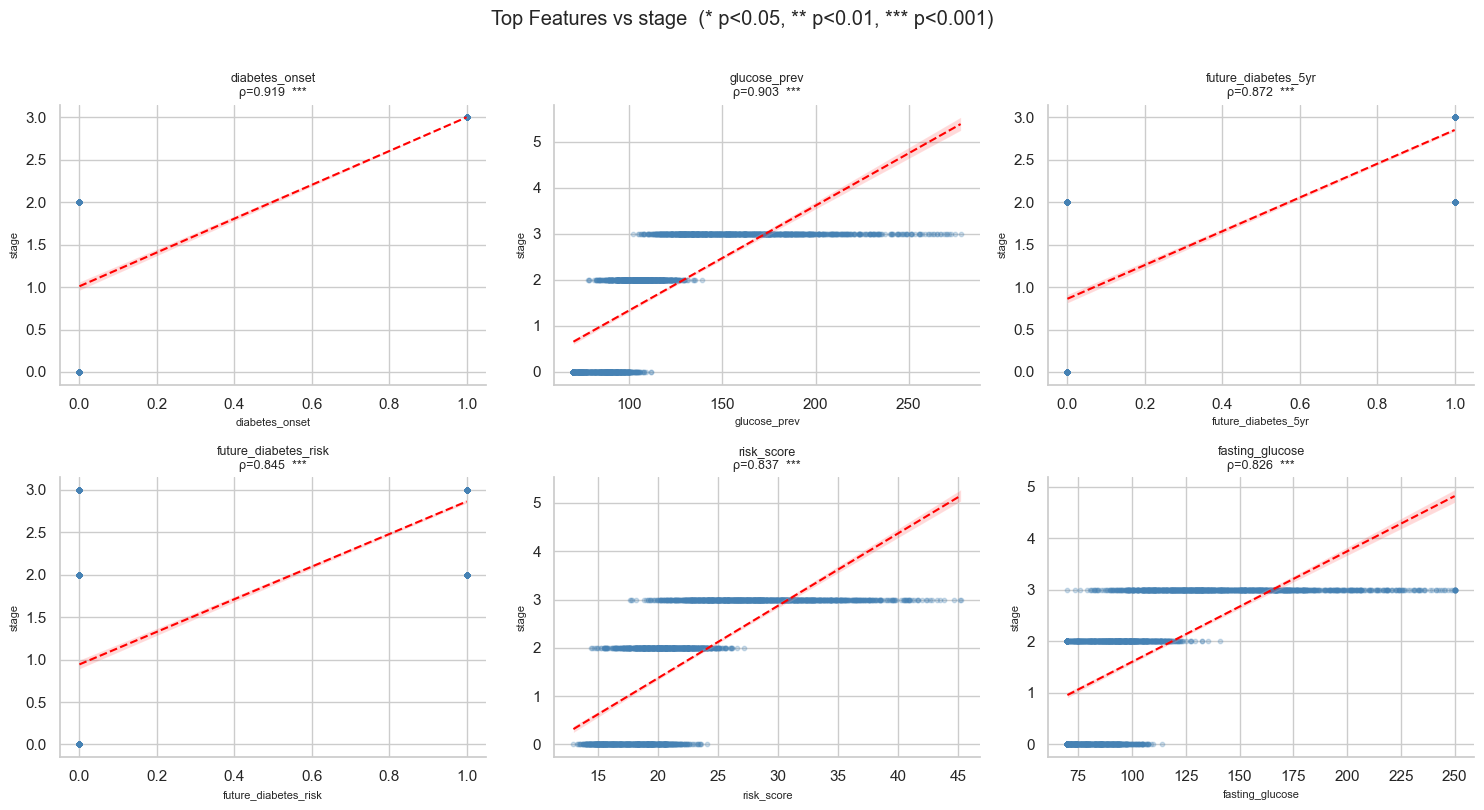

In [13]:
top_features = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    valid = df[[col, TARGET]].dropna()
    # Sample for speed if large
    sample = valid.sample(min(3000, len(valid)), random_state=42)
    sns.regplot(
        data=sample, x=col, y=TARGET,
        scatter_kws={'alpha': 0.25, 's': 10, 'color': 'steelblue'},
        line_kws={'color': 'red', 'linewidth': 1.5, 'linestyle': '--'},
        ax=axes[i]
    )
    rho, p = spearmanr(valid[col], valid[TARGET])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    axes[i].set_title(f'{col}\nρ={rho:.3f}  {sig}', fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel(TARGET, fontsize=8)
    sns.despine(ax=axes[i])

for j in range(len(top_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Top Features vs {TARGET}  (* p<0.05, ** p<0.01, *** p<0.001)', y=1.01)
plt.tight_layout()
plt.show()

## 9. Summary & Modelling Plan

### Answers to Research Questions

| # | Question | Finding |
|---|---|---|
| 1 | Target structure | `stage` ∈ {0, 1, 2, 3} — ordinal, 4 classes. Mean=1.88, std=1.24. Treat as regression (RMSE-based) or ordinal classification. |
| 2 | Clinical drivers | `fasting_glucose` (ρ=0.83), `HbA1c` (ρ=0.72), `BMI` (ρ=0.71), `HOMA_IR` (ρ=0.70) — core glycaemic biomarkers dominate. |
| 3 | Non-linearity | Divergence up to 0.17 (e.g. `fasting_glucose`: Pearson=0.67, Spearman=0.83) → strong non-linear signal → tree models expected to outperform Ridge. |
| 4 | Data quality | 0 missing in main features. `onset_year` has 43% missing (216k/496k) — drop. `alive`=1.0 for all rows — constant, drop. |
| 5 | Feature redundancy | `HbA1c` and `fasting_glucose` ρ≈0.85 (both measure glycaemic control) → multicollinearity risk for Ridge; LightGBM handles automatically. |

---

### ⚠ Leakage Warning — Critical Finding

The following columns have Spearman ρ > 0.84 with `stage` and are **likely derived from the target** or from future information:

| Column | Spearman ρ | Problem |
|---|---|---|
| `diabetes_onset` | 0.919 | Binary flag for diabetes diagnosis — encodes the outcome |
| `glucose_prev` | 0.903 | Previous glucose — future relative to some rows |
| `future_diabetes_5yr` | 0.872 | Explicitly future label |
| `future_diabetes_risk` | 0.845 | Risk score derived from outcome |
| `risk_score` | 0.837 | Composite score likely including stage |

**These must be excluded from the feature set before modelling.** Including them inflates R² artificially and makes the model useless in deployment (you wouldn't have future labels at prediction time).

---

### Modelling Plan

**Target:** `stage` ∈ {0,1,2,3}  
**Features (clean set, leakage removed):** `fasting_glucose`, `HbA1c`, `BMI`, `HOMA_IR`, `insulin`, `age`, `triglycerides`, `HDL`, `LDL`, `blood_pressure`, `daily_calories`, `sugar_intake`, `sleep_hours`, `stress_level`, `sedentary_hours`, `family_history`, `on_medication`, `smoking`, `alcohol`, `bmi_prev`  
**Drop:** `patient_id`, `alive`, `onset_year`, `diabetes_onset`, `glucose_prev`, `future_diabetes_5yr`, `future_diabetes_risk`, `risk_score`  
**Baseline:** DummyRegressor (mean)  
**Linear:** Ridge  
**Tree:** LightGBM — non-linearity confirmed by divergence analysis  
**Evaluation:** RMSE + Spearman ρ; if treating as classification → macro-AUC  
**Validation:** 5-Fold CV (i.i.d. cross-sectional data, no temporal ordering needed)
